## Imports e Conexão

In [3]:
import pandas as pd
from sqlalchemy import create_engine, text,inspect
import os

In [4]:
DATABASE_URL = os.getenv("DATABASE_URL")

engine = create_engine(DATABASE_URL)

try:
    # Teste de conexão
    with engine.connect() as conexao:
        resultado = conexao.execute(text("SELECT version();"))
        print(" Conexão bem-sucedida ao banco remoto!")
        print("Versão do banco:", resultado.fetchone()[0])

except Exception as e:
    print(" Erro ao conectar ao banco remoto:")
    print(e)


 Conexão bem-sucedida ao banco remoto!
Versão do banco: PostgreSQL 16.15 on x86_64-pc-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit


## Script para mapeamento de tabelas por schema

In [ ]:
# Criamos o inspetor do SQLAlchemy
inspetor = inspect(engine)
meus_schemas = ["geral", "rh", "vendas", "financeiro"]

relatorio_tabelas = []

for schema in meus_schemas:
    # Pegando tabela por schema
    tabelas = inspetor.get_table_names(schema=schema)
    
    for tabela in tabelas:
        # Pegando coluna por tabela
        colunas = inspetor.get_columns(tabela, schema=schema)
        nomes_colunas = [c['name'] for c in colunas]
        tipos_colunas = [str(c['type']) for c in colunas]
        
        relatorio_tabelas.append({
            "Schema": schema,
            "Tabela": tabela,
            "Qtd Colunas": len(nomes_colunas),
            "Colunas": ", ".join(nomes_colunas)
        })

df_mapa = pd.DataFrame(relatorio_tabelas)
print(df_mapa)

## Amostragem de dados

In [7]:
amostras = {}

for index, row in df_mapa.iterrows():
    schema = row['Schema']
    tabela = row['Tabela']
    
    query = f'SELECT * FROM "{schema}"."{tabela}" LIMIT 5;'
    
    try:
        df_amostra = pd.read_sql_query(text(query), engine)
        amostras[f"{schema}.{tabela}"] = df_amostra
        print(f" Amostra de {schema}.{tabela} carregada.")
    except Exception as e:
        print(f"Erro ao ler {schema}.{tabela}: {e}")

# amostras['schema_A.nome_da_tabela'].info()

 Amostra de geral.pessoa carregada.
 Amostra de geral.responsavel_juridico carregada.
 Amostra de geral.pessoa_fisica carregada.
 Amostra de geral.cidade carregada.
 Amostra de geral.estado carregada.
 Amostra de geral.contato carregada.
 Amostra de geral.bairro carregada.
 Amostra de geral.tipo_contato carregada.
 Amostra de geral.pessoa_juridica carregada.
 Amostra de geral.endereco carregada.
 Amostra de rh.lotacao carregada.
 Amostra de rh.escolaridade carregada.
 Amostra de rh.departamento carregada.
 Amostra de rh.funcionario carregada.
 Amostra de rh.cargo carregada.
 Amostra de vendas.produto carregada.
 Amostra de vendas.nota_fiscal carregada.
 Amostra de vendas.categoria carregada.
 Amostra de vendas.item_nota_fiscal carregada.
 Amostra de vendas.parcela carregada.
 Amostra de vendas.forma_pagamento carregada.
 Amostra de financeiro.conta_receber carregada.
 Amostra de financeiro.situacao_titulo carregada.
 Amostra de financeiro.conta_pagar carregada.


In [10]:
amostras['geral.pessoa'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             5 non-null      int64              
 1   data_cadastro  5 non-null      datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(1)
memory usage: 212.0 bytes


## Imagem do Diagrama (Sem Schema Financeiro)

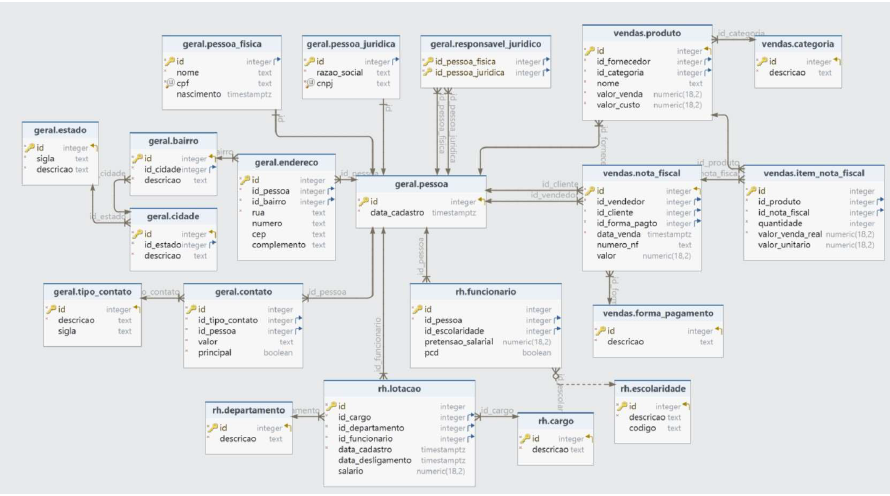

### Problema de negócio
A área de dados precisa estruturar uma camada analítica confiável a partir das vendas registradas no banco
operacional. Hoje, as informações estão distribuídas em tabelas relacionais, o que dificulta análises rápidas,
reprocessamentos e integração com outros sistemas.
A pergunta central do projeto é:
Como construir, com Python, um processo de extração, transformação e carga capaz de ler o modelo
relacional de vendas e preencher um DW simples, validado e documentado

### Objetivos

- Interpretar um modelo relacional existente e identificar as tabelas necessárias para análise de `vendas`.
- Conectar Python ao PostgreSQL utilizando bibliotecas apropriadas, como SQLAlchemy, psycopg2 e pandas.
- Extrair dados de tabelas relacionais e realizar transformações em DataFrames.
- Criar uma camada dimensional simples com tabelas de dimensão e fato.
- Carregar os dados transformados no DW usando Python.
- Implementar validações técnicas de qualidade, integridade e consistência da carga.
- Documentar origem dos campos, regras de transformação e decisões de modelagem.

O schema vendas será a principal fonte de dados, enquanto o schema geral será usado para enriquecer informações de clientes e vendedores.
- Destino: Data Warehouse simplificado
- Entregável principal: pipeline Python capaz de popular as dimensões e a fato de vendas garantindo integridade e idempotencia dos dados.